In [1]:
# STEP 1 — EDA Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv("../data/processed/us_top50_clean.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique songs:", df["song"].nunique())
print("Unique artists:", df["artist"].nunique())

Dataset shape: (27700, 10)
Date range: 2024-05-18 00:00:00 to 2025-11-27 00:00:00
Unique songs: 943
Unique artists: 297


In [2]:
# STEP 2 — Dataset Overview

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (27700, 10)

Column names:
['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']

Data types:
date               datetime64[ns]
position                    int64
song                       object
artist                     object
popularity                  int64
duration_ms                 int64
album_type                 object
total_tracks                int64
is_explicit                  bool
album_cover_url            object
dtype: object

Missing values:
date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64


## 2. Dataset Overview

The cleaned dataset contains daily observations from the US Top 50 playlist. This section provides a basic overview of the dataset structure, variables, data types, and missing values before visual analysis.

## 3. Playlist Ranking Distribution

The Top 50 playlist assigns each song a daily position from 1 to 50. This visualization shows the distribution of playlist observations across all ranking positions.

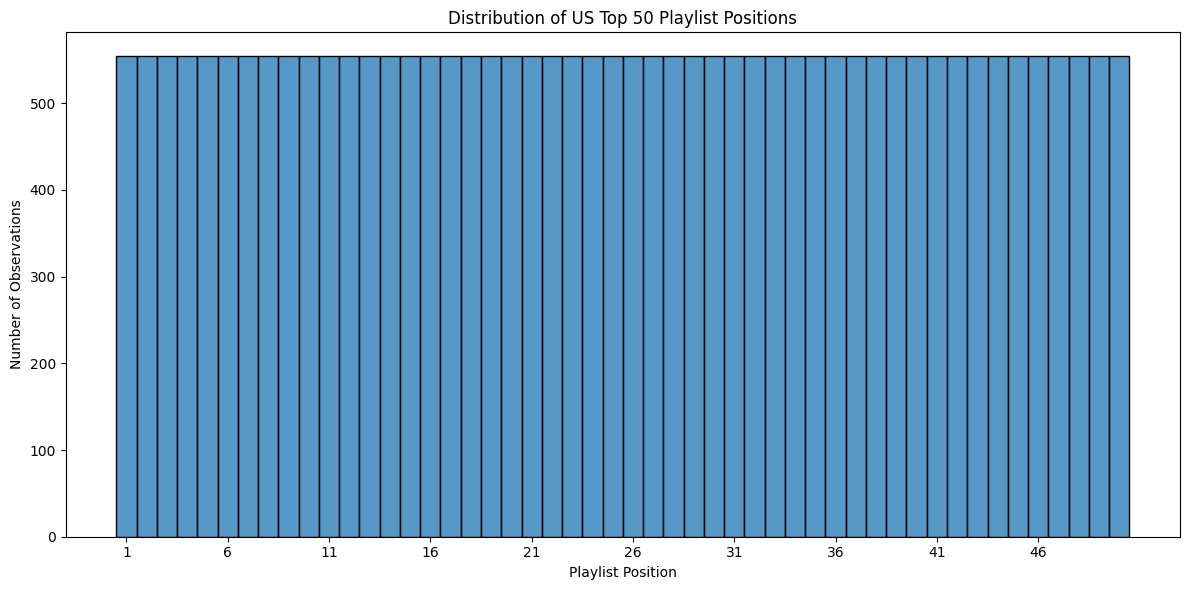

In [3]:
# STEP 3 — Playlist Ranking Distribution

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="position",
    bins=50,
    discrete=True
)

plt.title("Distribution of US Top 50 Playlist Positions")
plt.xlabel("Playlist Position")
plt.ylabel("Number of Observations")
plt.xticks(range(1, 51, 5))
plt.tight_layout()
plt.show()

## 4. Song Longevity

This analysis identifies songs that remained in the US Top 50 playlist for the longest number of days. Song longevity helps measure sustained chart presence rather than popularity on a single day.

In [4]:
# STEP 4 — Song Longevity

song_longevity = (
    df.groupby(["song", "artist"])
    .agg(
        chart_days=("date", "nunique"),
        best_position=("position", "min"),
        average_position=("position", "mean"),
        average_popularity=("popularity", "mean")
    )
    .reset_index()
    .sort_values("chart_days", ascending=False)
)

top_longevity = song_longevity.head(15)

top_longevity

,song,artist,chart_days,best_position,average_position,average_popularity
696,Something in the Orange,Zach Bryan,535,9,26.304673,88.366355
427,Last Night,Morgan Wallen,491,1,22.613035,85.674134
364,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,445,1,13.916854,90.076404
659,See You Again (feat. Kali Uchis),"Tyler, The Creator",443,4,29.340858,91.083521
709,Stick Season,Noah Kahan,413,1,18.322034,91.079903
170,Cruel Summer,Taylor Swift,387,1,16.925065,97.002584
444,Lose Control,Teddy Swims,328,5,23.536585,90.908537
790,Thinkin’ Bout Me,Morgan Wallen,323,21,39.046440,85.984520
99,Beautiful Things,Benson Boone,306,1,14.738562,90.800654
884,You Proof,Morgan Wallen,301,9,32.584718,84.661130


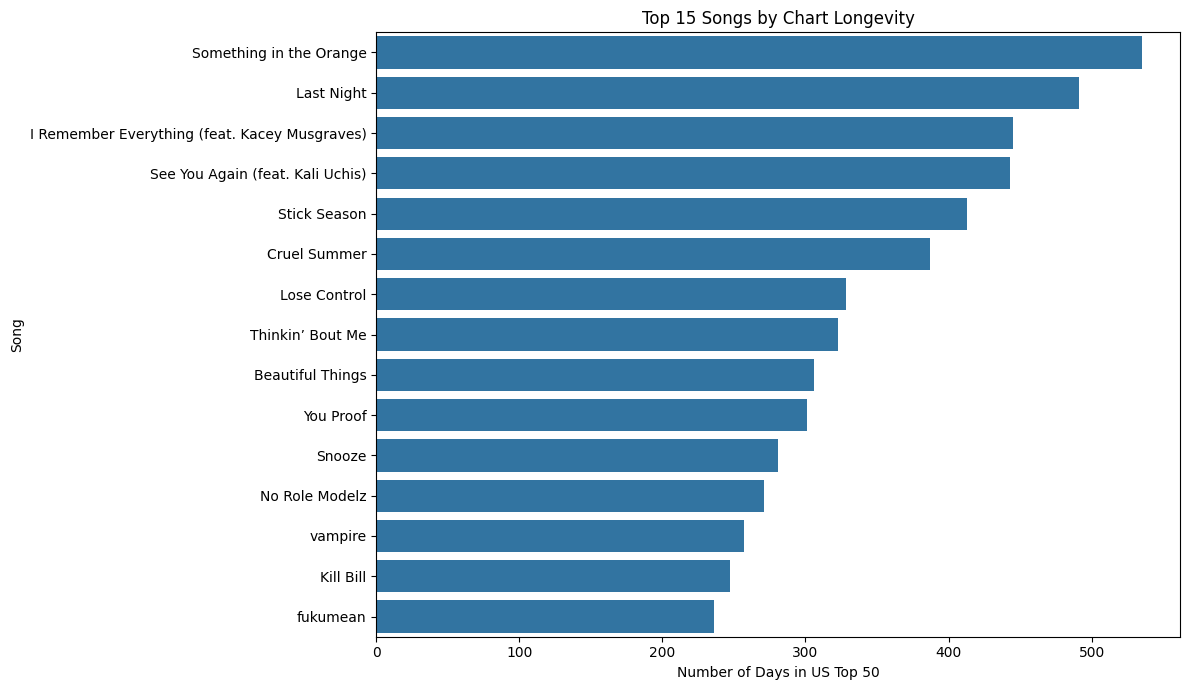

In [5]:
# STEP 4 — Top 15 Songs by Chart Longevity

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_longevity,
    y="song",
    x="chart_days"
)

plt.title("Top 15 Songs by Chart Longevity")
plt.xlabel("Number of Days in US Top 50")
plt.ylabel("Song")
plt.tight_layout()
plt.show()

## 5. Artist Dominance

This analysis identifies artists with the highest presence in the US Top 50 playlist. It considers playlist appearances and the number of unique songs represented by each artist.

In [6]:
# STEP 5 — Artist Dominance

artist_dominance = (
    df.groupby("artist")
    .agg(
        playlist_appearances=("song", "count"),
        unique_songs=("song", "nunique"),
        average_position=("position", "mean"),
        average_popularity=("popularity", "mean")
    )
    .reset_index()
    .sort_values("playlist_appearances", ascending=False)
)

top_artists = artist_dominance.head(15)

top_artists

,artist,playlist_appearances,unique_songs,average_position,average_popularity
242,Taylor Swift,2014,96,24.557100,87.096822
286,Zach Bryan,1854,35,25.619202,86.022114
177,Morgan Wallen,1666,10,30.610444,85.405762
229,Sabrina Carpenter,966,14,17.598344,90.198758
65,Drake,838,35,26.256563,84.608592
40,Chappell Roan,794,6,20.647355,88.664987
266,Travis Scott,760,31,25.744737,88.588158
22,Billie Eilish,729,12,20.362140,92.770919
273,"Tyler, The Creator",705,16,25.259574,88.394326
227,SZA,646,3,26.238390,91.668731


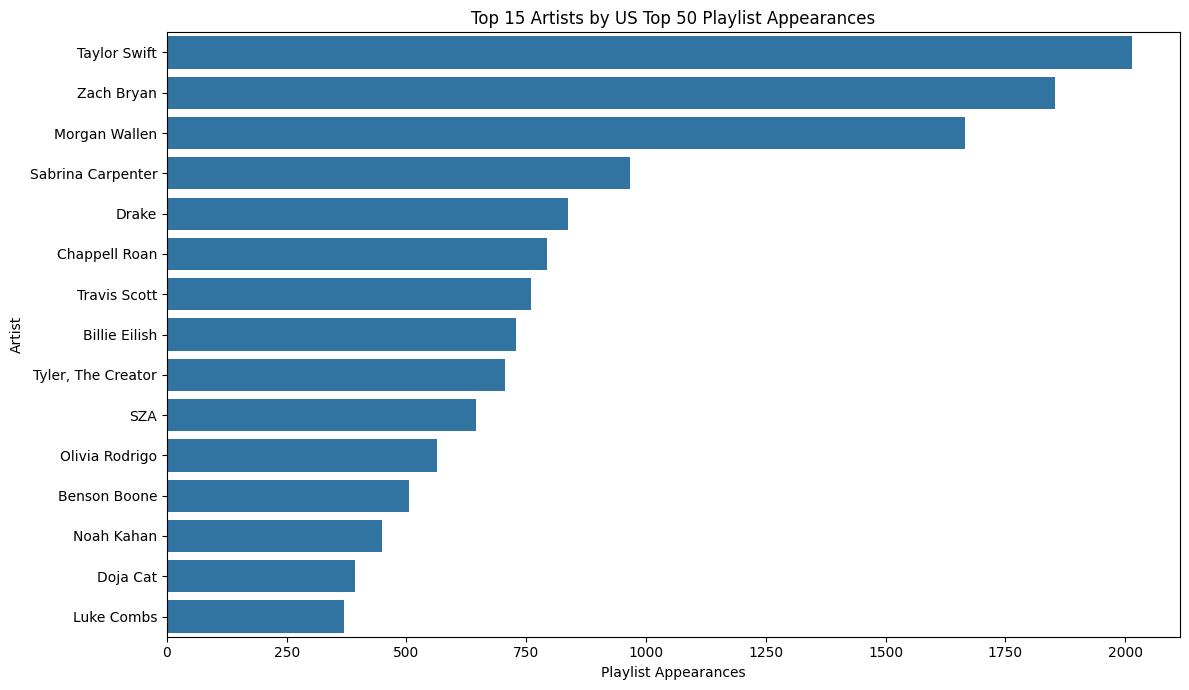

In [7]:
# STEP 5 — Top 15 Artists by Playlist Appearances

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_artists,
    y="artist",
    x="playlist_appearances"
)

plt.title("Top 15 Artists by US Top 50 Playlist Appearances")
plt.xlabel("Playlist Appearances")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

## 6. Popularity vs Chart Position

This analysis examines the relationship between Spotify popularity and playlist position. Average popularity is calculated for each chart position to identify whether more popular songs tend to occupy higher positions in the US Top 50.

In [8]:
# STEP 6 — Popularity vs Chart Position

position_popularity = (
    df.groupby("position")
      .agg(
          average_popularity=("popularity", "mean"),
          median_popularity=("popularity", "median"),
          song_observations=("song", "count")
      )
      .reset_index()
)

position_popularity.head()

,position,average_popularity,median_popularity,song_observations
0,1,89.055957,93.0,554
1,2,90.877256,94.0,554
2,3,90.557762,94.0,554
3,4,91.077617,94.0,554
4,5,90.745487,94.0,554


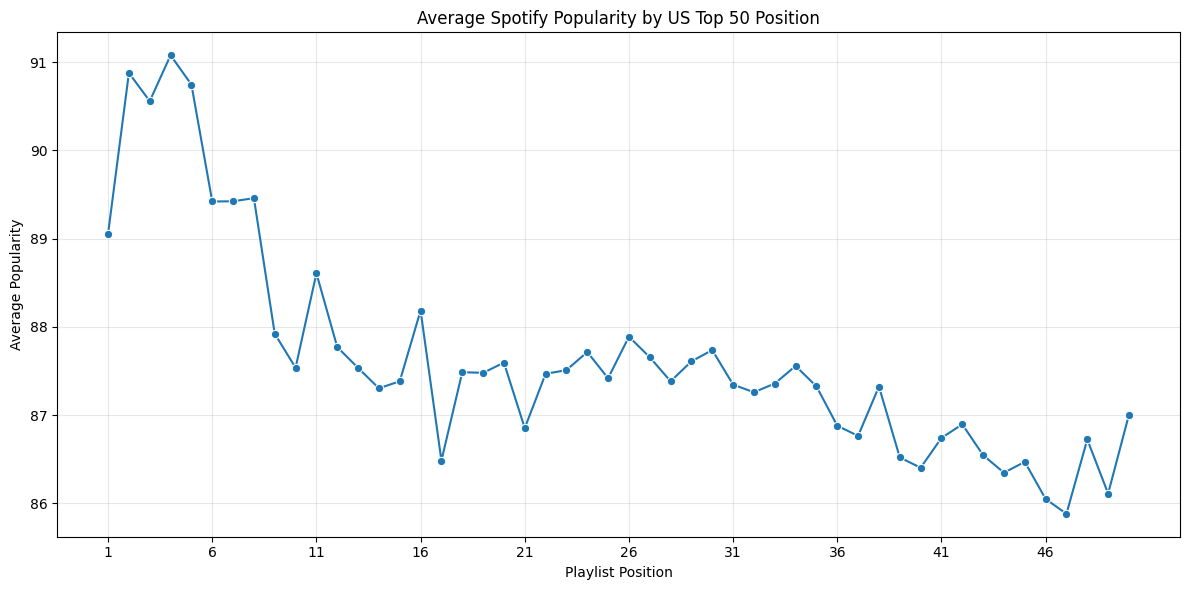

In [9]:
# STEP 6 — Visualization

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=position_popularity,
    x="position",
    y="average_popularity",
    marker="o"
)

plt.title("Average Spotify Popularity by US Top 50 Position")
plt.xlabel("Playlist Position")
plt.ylabel("Average Popularity")
plt.xticks(range(1, 51, 5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Popularity Across Rank Groups

This analysis compares average Spotify popularity across three playlist rank groups: Top 10, Top 20, and Top 50. It helps identify whether songs appearing closer to the top of the playlist have higher average popularity.

In [10]:
# STEP 7 — Popularity Across Rank Groups

df["rank_group"] = pd.cut(
    df["position"],
    bins=[0, 10, 20, 50],
    labels=["Top 10", "Top 20", "Top 50"]
)

rank_group_analysis = (
    df.groupby("rank_group", observed=False)
      .agg(
          average_popularity=("popularity", "mean"),
          median_popularity=("popularity", "median"),
          song_observations=("song", "count")
      )
      .reset_index()
)

rank_group_analysis

,rank_group,average_popularity,median_popularity,song_observations
0,Top 10,89.607220,93.0,5540
1,Top 20,87.582310,89.0,5540
2,Top 50,87.024128,88.0,16620


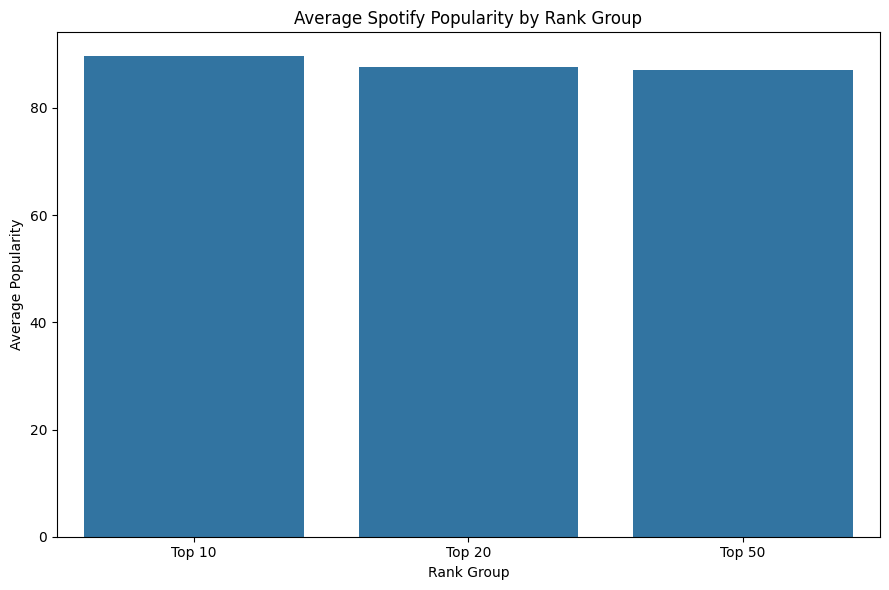

In [11]:
# STEP 7 — Visualization

plt.figure(figsize=(9, 6))

sns.barplot(
    data=rank_group_analysis,
    x="rank_group",
    y="average_popularity"
)

plt.title("Average Spotify Popularity by Rank Group")
plt.xlabel("Rank Group")
plt.ylabel("Average Popularity")
plt.tight_layout()
plt.show()

## 8. Explicit vs Non-Explicit Song Performance

This analysis compares explicit and non-explicit songs using playlist position and popularity. It helps identify differences in chart performance between the two content categories.

In [12]:
# STEP 8 — Explicit vs Non-Explicit Performance

explicit_analysis = (
    df.groupby("is_explicit")
      .agg(
          song_observations=("song", "count"),
          unique_songs=("song", "nunique"),
          average_position=("position", "mean"),
          median_position=("position", "median"),
          average_popularity=("popularity", "mean"),
          median_popularity=("popularity", "median")
      )
      .reset_index()
)

explicit_analysis["content_type"] = explicit_analysis["is_explicit"].map({
    False: "Non-Explicit",
    True: "Explicit"
})

explicit_analysis

,is_explicit,song_observations,unique_songs,average_position,median_position,average_popularity,median_popularity,content_type
0,False,14427,458,25.598531,25.0,87.981146,89.0,Non-Explicit
1,True,13273,499,25.392903,26.0,87.295035,89.0,Explicit


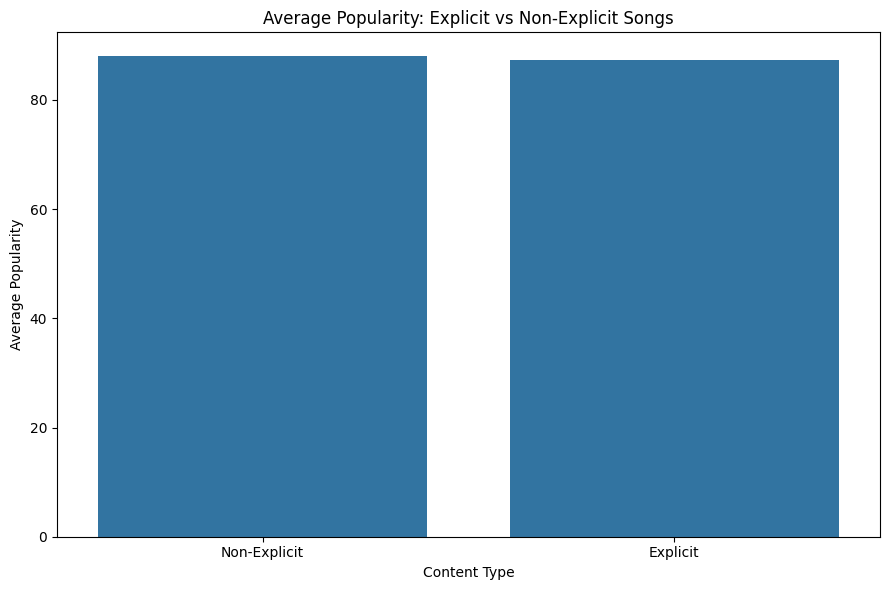

In [13]:
# STEP 8 — Visualization

plt.figure(figsize=(9, 6))

sns.barplot(
    data=explicit_analysis,
    x="content_type",
    y="average_popularity"
)

plt.title("Average Popularity: Explicit vs Non-Explicit Songs")
plt.xlabel("Content Type")
plt.ylabel("Average Popularity")
plt.tight_layout()
plt.show()

## 9. Song Duration Analysis

This analysis examines song duration in relation to playlist position and popularity. Song duration is converted from milliseconds to minutes to make the results easier to interpret.

In [14]:
df["duration_minutes"] = df["duration_ms"] / 60000

In [15]:
# STEP 9 — Duration Analysis

duration_analysis = (
    df.groupby("rank_group", observed=False)
      .agg(
          average_duration_minutes=("duration_minutes", "mean"),
          median_duration_minutes=("duration_minutes", "median"),
          average_popularity=("popularity", "mean")
      )
      .reset_index()
)

duration_analysis

,rank_group,average_duration_minutes,median_duration_minutes,average_popularity
0,Top 10,3.324097,3.106083,89.607220
1,Top 20,3.383464,3.248667,87.582310
2,Top 50,3.282506,3.128717,87.024128


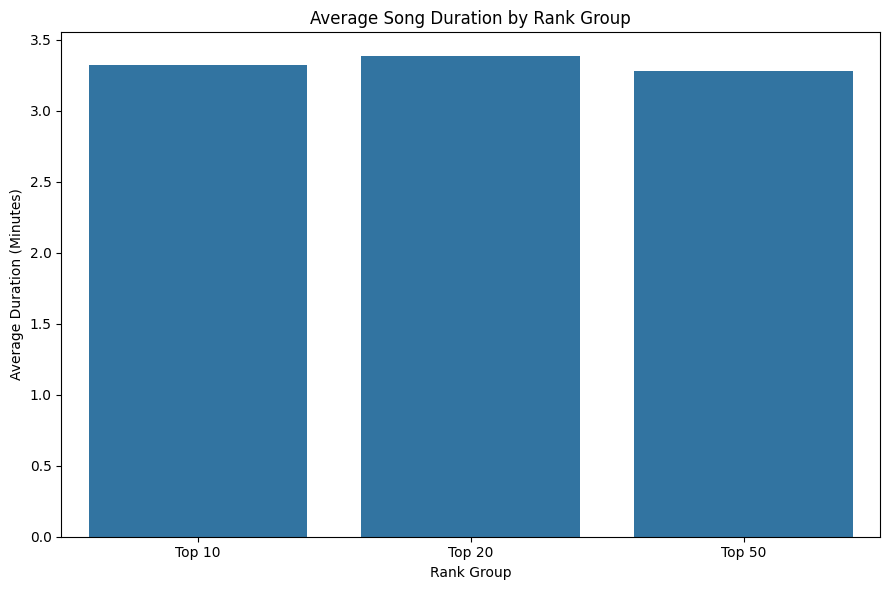

In [16]:
# STEP 9 — Visualization

plt.figure(figsize=(9, 6))

sns.barplot(
    data=duration_analysis,
    x="rank_group",
    y="average_duration_minutes"
)

plt.title("Average Song Duration by Rank Group")
plt.xlabel("Rank Group")
plt.ylabel("Average Duration (Minutes)")
plt.tight_layout()
plt.show()

## 10. Album Type Performance

This analysis compares playlist performance across album types, including Single, Album, and Compilation tracks. Performance is evaluated using playlist position, popularity, and the number of playlist observations.

In [17]:
# STEP 10 — Album Type Performance

album_type_analysis = (
    df.groupby("album_type")
      .agg(
          playlist_observations=("song", "count"),
          unique_songs=("song", "nunique"),
          average_position=("position", "mean"),
          median_position=("position", "median"),
          average_popularity=("popularity", "mean"),
          median_popularity=("popularity", "median")
      )
      .reset_index()
)

album_type_analysis

,album_type,playlist_observations,unique_songs,average_position,median_position,average_popularity,median_popularity
0,album,19672,745,26.095821,26.0,86.667751,88.0
1,compilation,42,8,33.190476,36.0,78.380952,82.0
2,single,7986,239,23.991861,23.0,90.126597,91.0


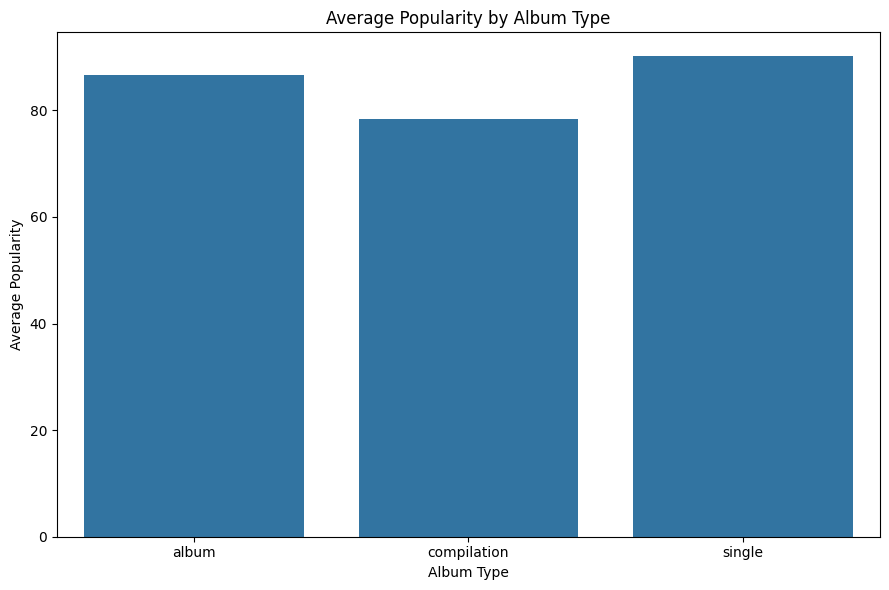

In [18]:
# STEP 10 — Visualization

plt.figure(figsize=(9, 6))

sns.barplot(
    data=album_type_analysis,
    x="album_type",
    y="average_popularity"
)

plt.title("Average Popularity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Average Popularity")
plt.tight_layout()
plt.show()

## Popularity vs Playlist Position

This visualization examines the relationship between playlist position and track popularity.

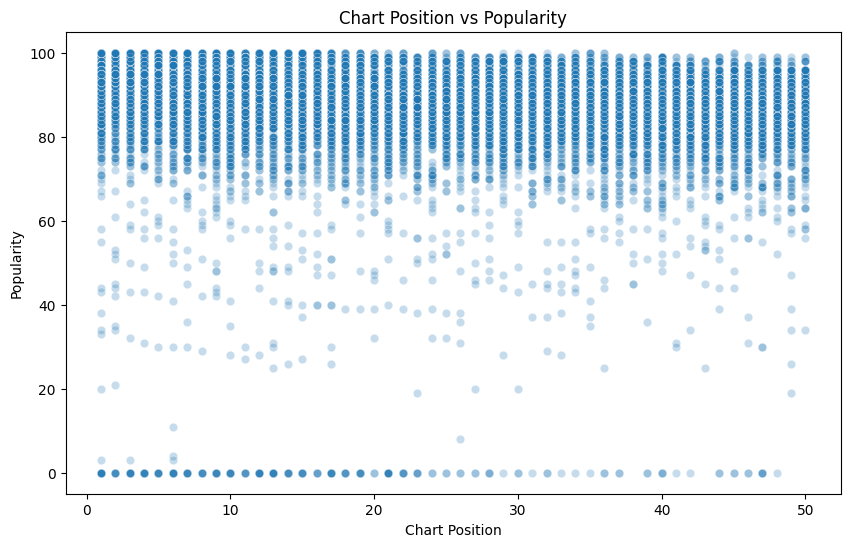

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="position",
    y="popularity",
    alpha=0.25
)

plt.title("Chart Position vs Popularity")
plt.xlabel("Chart Position")
plt.ylabel("Popularity")
plt.show()

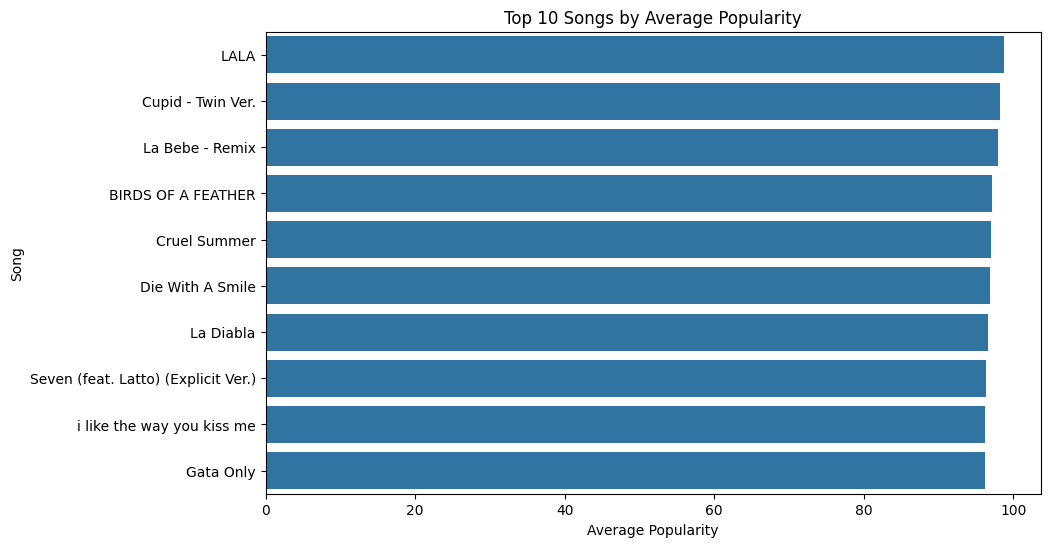

In [20]:
top_songs = (
    df.groupby("song")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_songs.values,
    y=top_songs.index
)

plt.title("Top 10 Songs by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Song")
plt.show()

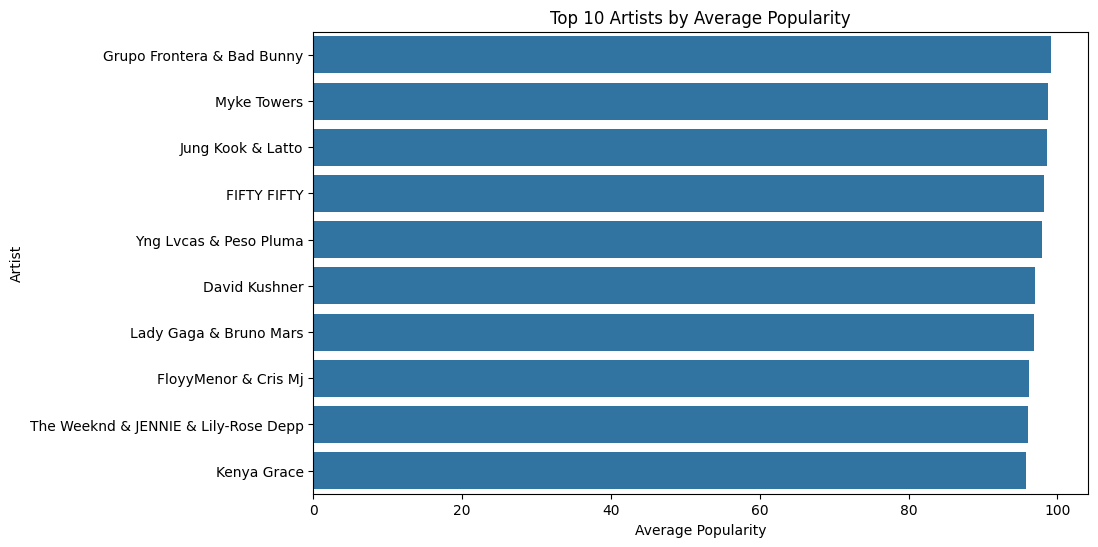

In [21]:
top_artists = (
    df.groupby("artist")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top 10 Artists by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Artist")
plt.show()

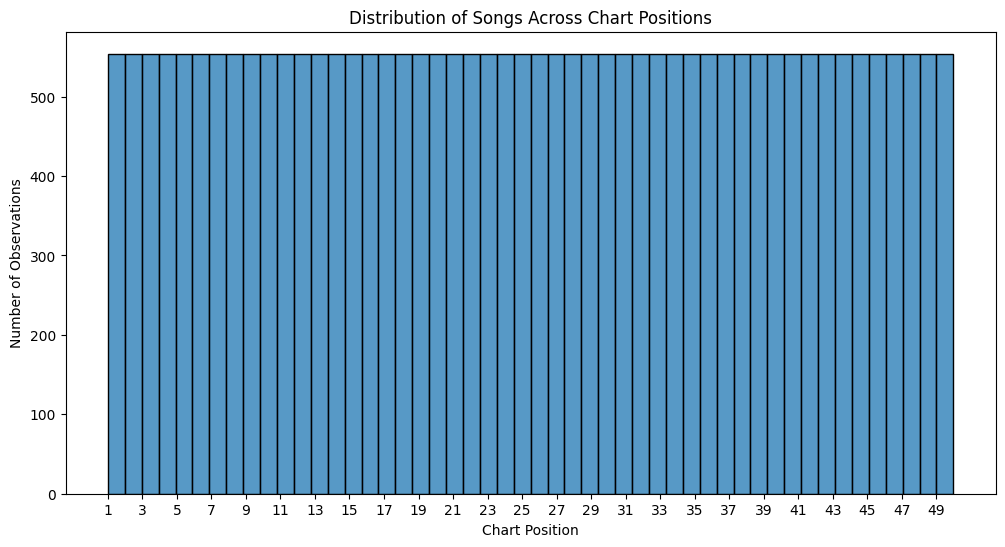

In [22]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="position",
    bins=50
)

plt.title("Distribution of Songs Across Chart Positions")
plt.xlabel("Chart Position")
plt.ylabel("Number of Observations")
plt.xticks(range(1, 51, 2))
plt.show()

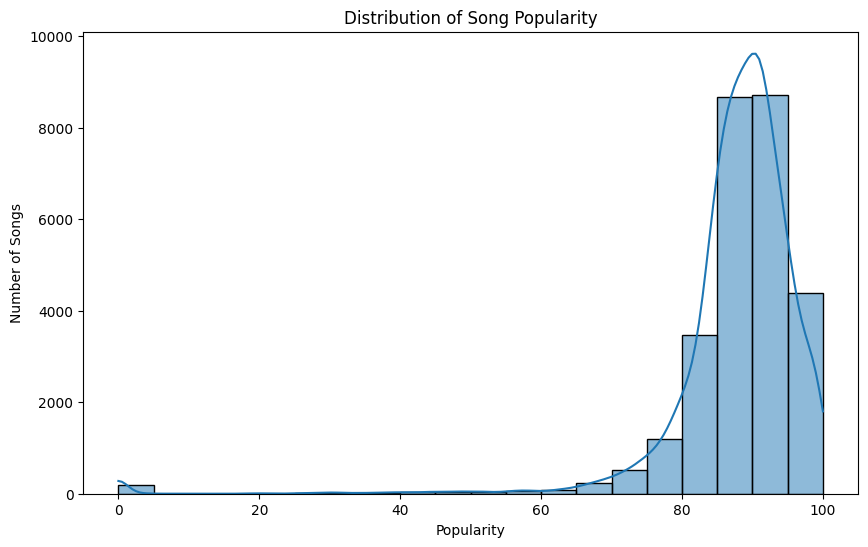

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="popularity",
    bins=20,
    kde=True
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

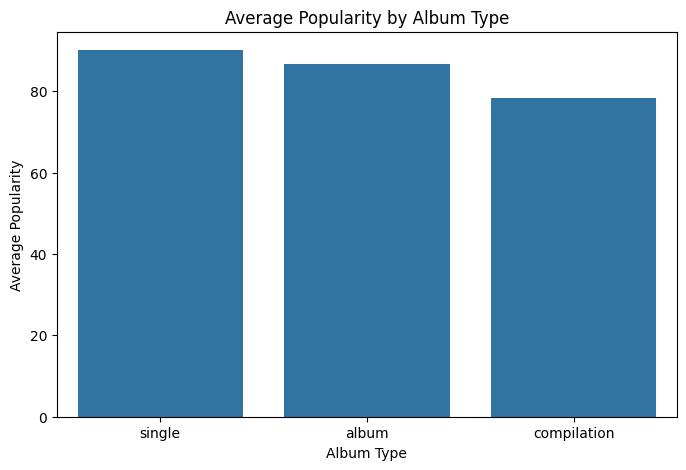

In [24]:
album_popularity = (
    df.groupby("album_type")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=album_popularity.index,
    y=album_popularity.values
)

plt.title("Average Popularity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Average Popularity")
plt.show()

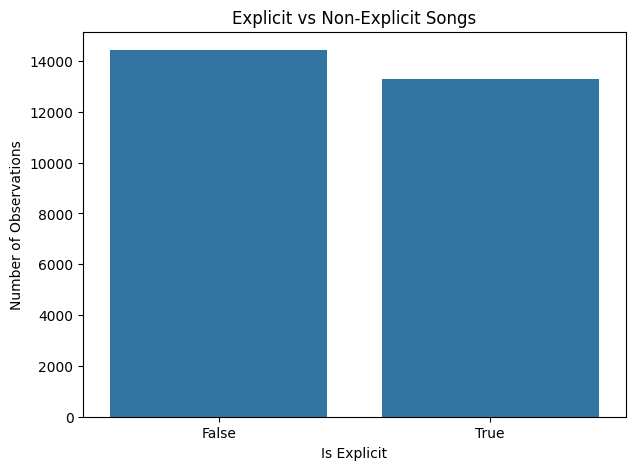

In [25]:
explicit_counts = df["is_explicit"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=explicit_counts.index.astype(str),
    y=explicit_counts.values
)

plt.title("Explicit vs Non-Explicit Songs")
plt.xlabel("Is Explicit")
plt.ylabel("Number of Observations")
plt.show()

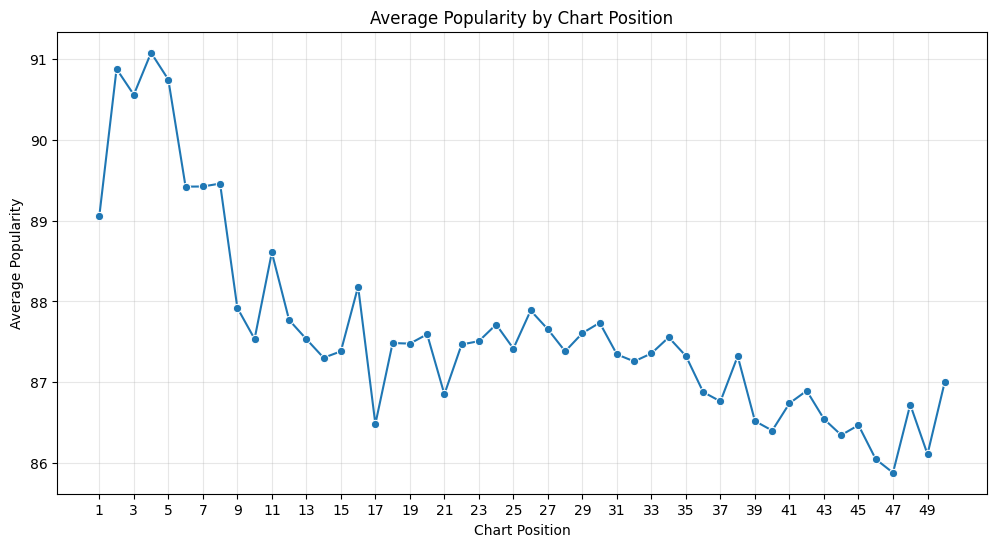

In [26]:
position_popularity = (
    df.groupby("position")["popularity"]
    .mean()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=position_popularity.index,
    y=position_popularity.values,
    marker="o"
)

plt.title("Average Popularity by Chart Position")
plt.xlabel("Chart Position")
plt.ylabel("Average Popularity")
plt.xticks(range(1, 51, 2))
plt.grid(alpha=0.3)
plt.show()

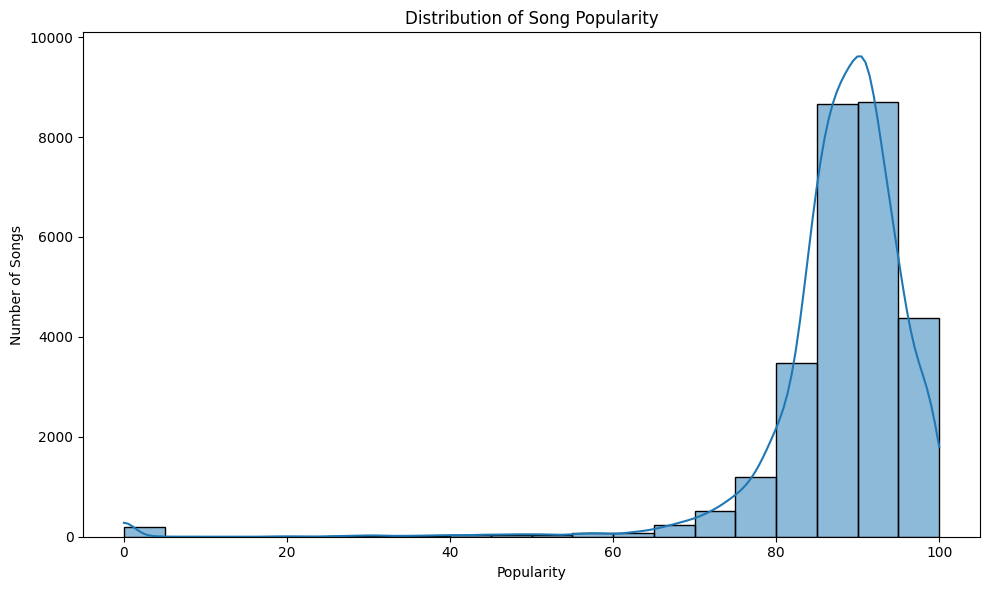

In [27]:
# Popularity Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="popularity",
    bins=20,
    kde=True
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

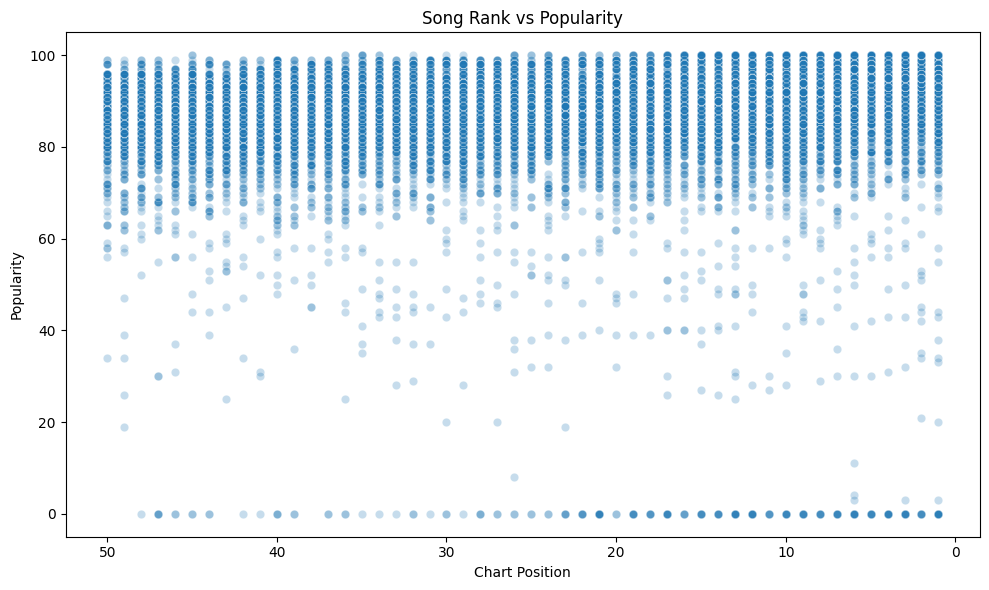

In [28]:
# Rank vs Popularity

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="position",
    y="popularity",
    alpha=0.25
)

plt.title("Song Rank vs Popularity")
plt.xlabel("Chart Position")
plt.ylabel("Popularity")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

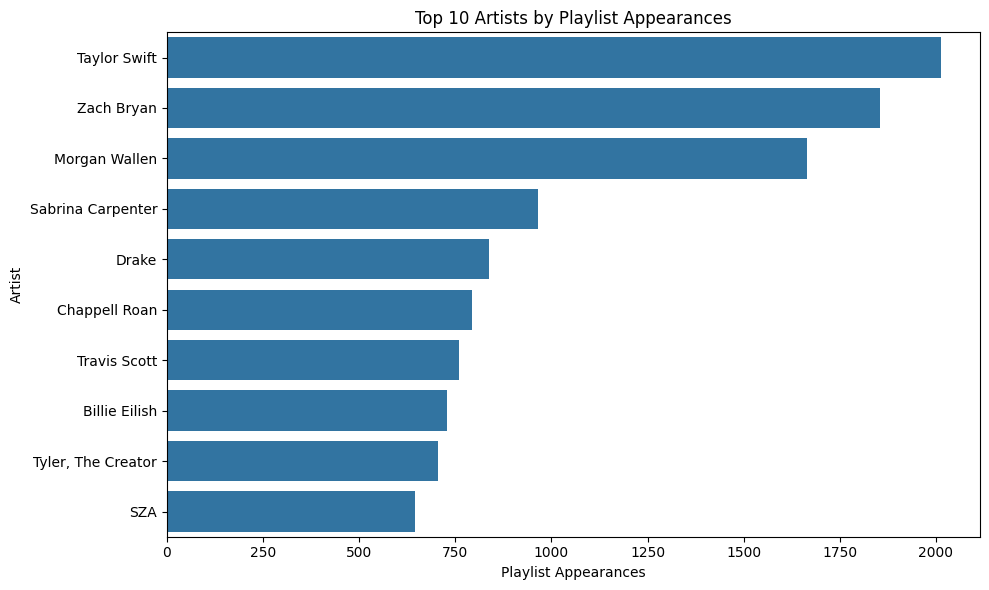

In [29]:
# Top 10 Artists by Playlist Appearances

top_artists = (
    df.groupby("artist")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top 10 Artists by Playlist Appearances")
plt.xlabel("Playlist Appearances")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

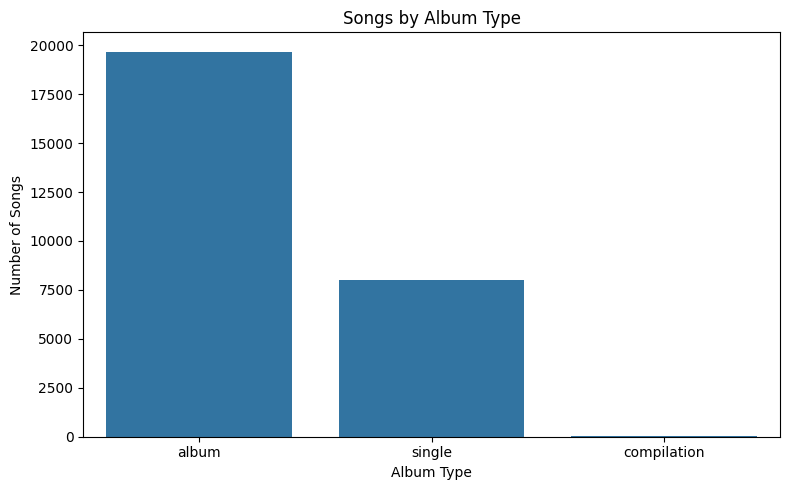

In [30]:
# Album Type Comparison

album_counts = df["album_type"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=album_counts.index,
    y=album_counts.values
)

plt.title("Songs by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

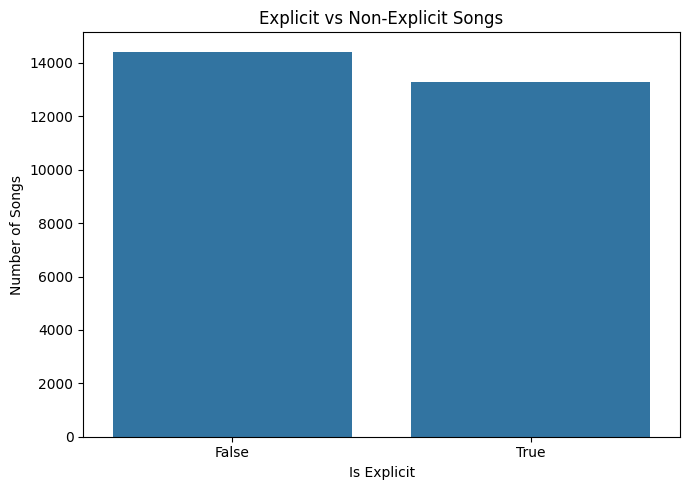

In [31]:
# Explicit vs Non-Explicit Songs

explicit_counts = df["is_explicit"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=explicit_counts.index.astype(str),
    y=explicit_counts.values
)

plt.title("Explicit vs Non-Explicit Songs")
plt.xlabel("Is Explicit")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

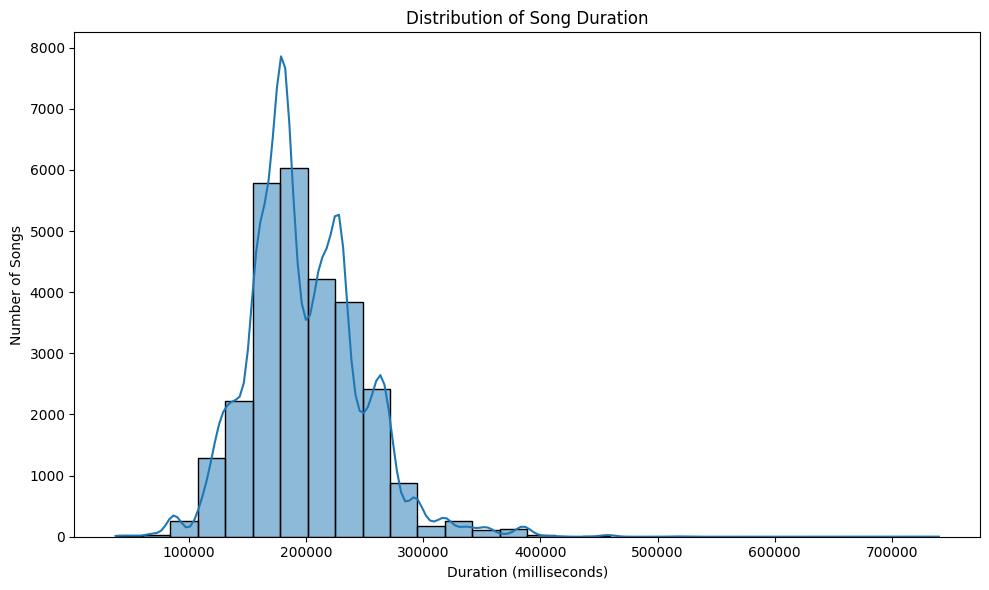

In [32]:
# Song Duration Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="duration_ms",
    bins=30,
    kde=True
)

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (milliseconds)")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

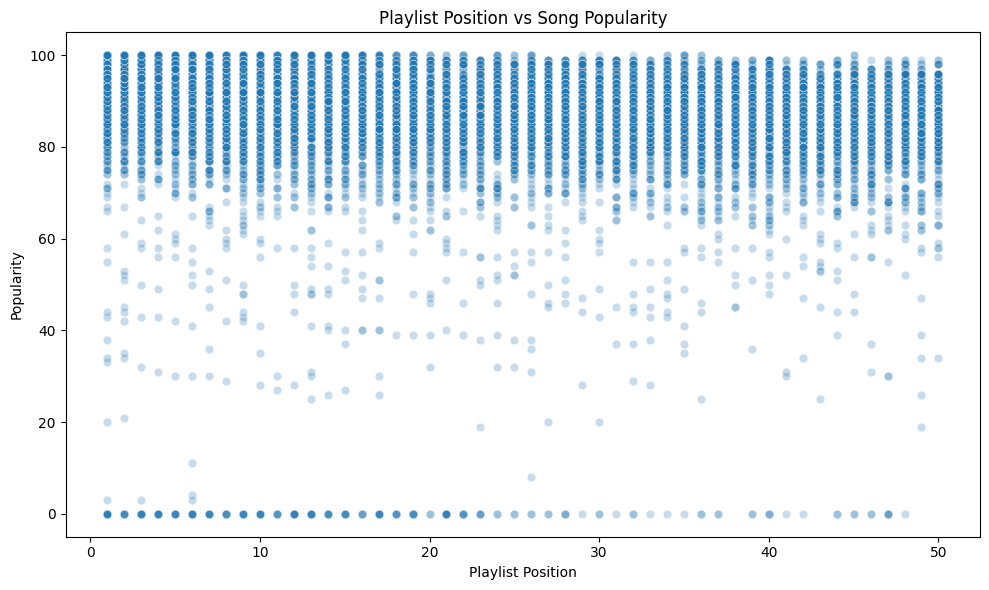

In [33]:
# Position vs Popularity

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="position",
    y="popularity",
    alpha=0.25
)

plt.title("Playlist Position vs Song Popularity")
plt.xlabel("Playlist Position")
plt.ylabel("Popularity")
plt.tight_layout()
plt.show()

In [34]:
# Spearman correlation between position and popularity

correlation = df["position"].corr(df["popularity"], method="spearman")

print(f"Spearman correlation between position and popularity: {correlation:.3f}")

Spearman correlation between position and popularity: -0.245


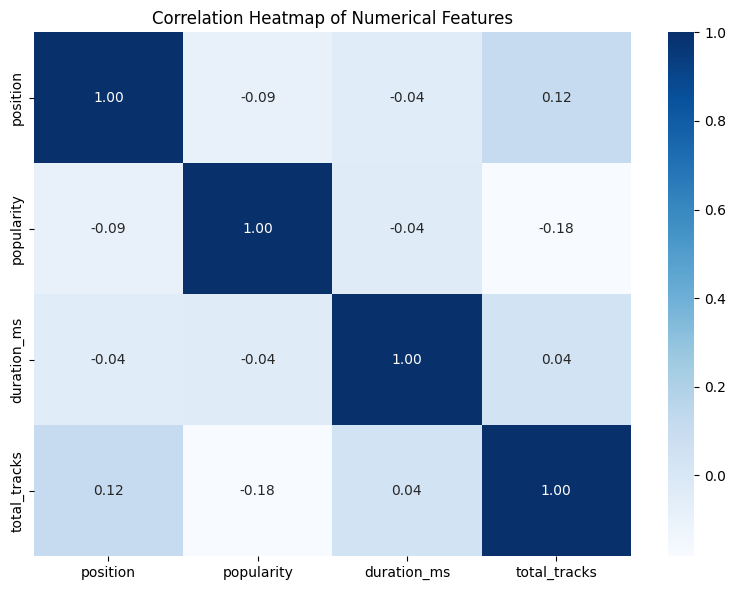

In [35]:
# Correlation Heatmap

correlation_data = df[
    ["position", "popularity", "duration_ms", "total_tracks"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [36]:
# Final EDA validation

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("EDA completed successfully.")

Dataset shape: (27700, 12)
Missing values: 0
Duplicate rows: 0
EDA completed successfully.
